# 03 · Edges

**What this teaches:** the four ways control flows through a graph — plain edges,
parallel branches, conditional edges, and routing decided inside the node itself.

The example is a triangle classifier: measure the sides, then branch to whichever
node describes that kind of triangle.

## What is an edge?

From the [Graph API docs](https://docs.langchain.com/oss/python/langgraph/graph-api#edges):

> **Edges** are "functions that determine which Node to execute next based on the
> current state. They can be conditional branches or fixed transitions."

| Pattern | Who decides the next node | Built with |
| --- | --- | --- |
| Normal edge | nobody — it is fixed | `add_edge("a", "b")` |
| Parallel | fixed, but several at once | two `add_edge` calls from one node |
| Conditional edge | a separate router function | `add_conditional_edges("a", route)` |
| In-node routing | the node itself | `return Command(goto=...)` |

In [1]:
import operator
from typing import Annotated, Literal

from IPython.display import Image, display
from langgraph.errors import InvalidUpdateError
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command
from typing_extensions import TypedDict

In [2]:
def show(graph):
    """Draw the graph. Falls back to Mermaid source if mermaid.ink is unreachable."""
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        print(graph.get_graph().draw_mermaid())

The three side lengths are the input. `notes` carries the accumulating reducer from
02, so every node's contribution stays visible in the final result.

In [3]:
class Triangle(TypedDict):
    sides: list[float]
    notes: Annotated[list[str], operator.add]

## 1. Normal edges

A [normal edge](https://docs.langchain.com/oss/python/langgraph/graph-api#normal-edges)
is used when you *always* want to go from one node to the next.

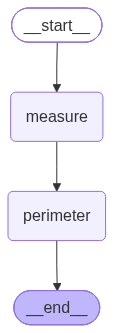

In [4]:
def measure(state: Triangle) -> dict:
    a, b, c = state["sides"]
    print("---measure---")
    return {"notes": [f"sides {a}, {b}, {c}"]}


def perimeter(state: Triangle) -> dict:
    print("---perimeter---")
    return {"notes": [f"perimeter = {sum(state['sides'])}"]}


serial = StateGraph(Triangle)
serial.add_node("measure", measure)
serial.add_node("perimeter", perimeter)

serial.add_edge(START, "measure")
serial.add_edge("measure", "perimeter")
serial.add_edge("perimeter", END)

serial_graph = serial.compile()
show(serial_graph)

In [5]:
serial_graph.invoke({"sides": [3, 4, 5], "notes": []})

---measure---
---perimeter---


{'sides': [3, 4, 5], 'notes': ['sides 3, 4, 5', 'perimeter = 12']}

## 2. Parallel branches

Add **two** edges out of the same node and both targets run at the same time.

LangGraph executes in **supersteps**: every node reachable in the current step runs
together, their updates are merged, and only then does the next step begin. Perimeter
and longest-side do not depend on each other, so they can share a step.

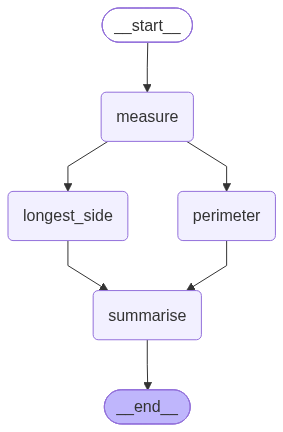

In [6]:
def longest_side(state: Triangle) -> dict:
    print("---longest_side---")
    return {"notes": [f"longest side = {max(state['sides'])}"]}


def summarise(state: Triangle) -> dict:
    print(f"---summarise--- sees {len(state['notes'])} notes")
    return {"notes": ["summary complete"]}


diamond = StateGraph(Triangle)
diamond.add_node("measure", measure)
diamond.add_node("perimeter", perimeter)
diamond.add_node("longest_side", longest_side)
diamond.add_node("summarise", summarise)

diamond.add_edge(START, "measure")
diamond.add_edge("measure", "perimeter")        # fan out
diamond.add_edge("measure", "longest_side")     # fan out
diamond.add_edge("perimeter", "summarise")      # fan in
diamond.add_edge("longest_side", "summarise")   # fan in
diamond.add_edge("summarise", END)

diamond_graph = diamond.compile()
show(diamond_graph)

In [7]:
diamond_graph.invoke({"sides": [3, 4, 5], "notes": []})

---measure---
---longest_side---
---perimeter---
---summarise--- sees 3 notes


{'sides': [3, 4, 5],
 'notes': ['sides 3, 4, 5',
  'longest side = 5',
  'perimeter = 12',
  'summary complete']}

### Why parallel branches need a reducer

`perimeter` and `longest_side` both write `notes` in the same superstep. Without a
reducer LangGraph has two competing values for one key and no rule for combining them:

In [8]:
class NoReducer(TypedDict):
    sides: list[float]
    notes: list[str]                # note: no Annotated


def plain(label):
    def node(state: NoReducer) -> dict:
        return {"notes": [label]}

    return node


broken = StateGraph(NoReducer)
for name in ["measure", "perimeter", "longest_side", "summarise"]:
    broken.add_node(name, plain(name))

broken.add_edge(START, "measure")
broken.add_edge("measure", "perimeter")
broken.add_edge("measure", "longest_side")
broken.add_edge("perimeter", "summarise")
broken.add_edge("longest_side", "summarise")
broken.add_edge("summarise", END)

try:
    broken.compile().invoke({"sides": [3, 4, 5], "notes": []})
except InvalidUpdateError as e:
    print("InvalidUpdateError:", e)

InvalidUpdateError: At key 'notes': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


> "At key 'notes': Can receive only one value per step. Use an Annotated key to handle
> multiple values."

This is why 02 came before 03. The reducer is what makes concurrency expressible.

## 3. Conditional edges

A [conditional edge](https://docs.langchain.com/oss/python/langgraph/graph-api#conditional-edges)
lets you "optionally route to one or more edges (or optionally terminate)".

It is a function that takes the state and returns the **name of the next node**. It
returns a name and nothing else — it cannot change the state.

A triangle is *equilateral* if all three sides are equal, *isosceles* if exactly two
are, and *scalene* if none are.

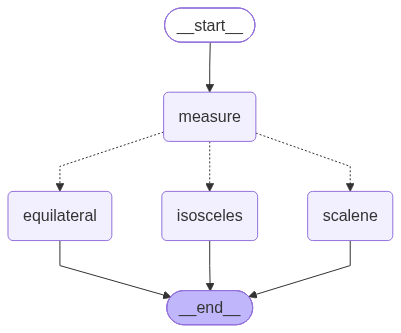

In [9]:
def classify(state: Triangle) -> Literal["equilateral", "isosceles", "scalene"]:
    """Count how many distinct side lengths there are."""
    distinct = len(set(state["sides"]))
    if distinct == 1:
        return "equilateral"
    if distinct == 2:
        return "isosceles"
    return "scalene"


def equilateral(state: Triangle) -> dict:
    return {"notes": ["equilateral: all three sides equal"]}


def isosceles(state: Triangle) -> dict:
    return {"notes": ["isosceles: exactly two sides equal"]}


def scalene(state: Triangle) -> dict:
    return {"notes": ["scalene: no two sides equal"]}


routed = StateGraph(Triangle)
routed.add_node("measure", measure)
routed.add_node("equilateral", equilateral)
routed.add_node("isosceles", isosceles)
routed.add_node("scalene", scalene)

routed.add_edge(START, "measure")
routed.add_conditional_edges("measure", classify)   # <- instead of add_edge
routed.add_edge("equilateral", END)
routed.add_edge("isosceles", END)
routed.add_edge("scalene", END)

routed_graph = routed.compile()
show(routed_graph)

The dashed lines out of `measure` are the conditional ones. The `Literal[...]` return
annotation is what tells the renderer which destinations are possible.

In [10]:
for sides in ([3, 3, 3], [5, 5, 8], [3, 4, 5]):
    print(sides, "->", routed_graph.invoke({"sides": sides, "notes": []})["notes"][-1])

---measure---
[3, 3, 3] -> equilateral: all three sides equal
---measure---
[5, 5, 8] -> isosceles: exactly two sides equal
---measure---
[3, 4, 5] -> scalene: no two sides equal


`measure` runs in every case, then the router reads the state and sends execution to
exactly one of the three describing nodes.

## 4. Routing from inside the node

The router above lives outside the node. Often you want the opposite — as the
[docs](https://docs.langchain.com/oss/python/langgraph/use-graph-api) put it:

> "It can be useful to combine control flow (edges) and state updates (nodes). For
> example, you might want to BOTH perform state updates AND decide which node to go to
> next in the SAME node."

[`Command`](https://docs.langchain.com/oss/python/langgraph/graph-api#command) is "a
versatile primitive for controlling graph execution". Return one and it carries both
halves: `update=` is the state change, `goto=` is the edge.

Two details are easy to miss:

1. **There is no `add_edge` out of `measure`.** The `goto` supplies it.
2. **The return annotation `Command[Literal[...]]` is required for the diagram.**
   Without it the drawing shows the node with no outgoing edges.

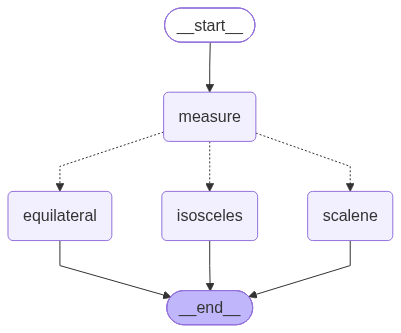

In [11]:
def measure_and_classify(
    state: Triangle,
) -> Command[Literal["equilateral", "isosceles", "scalene"]]:
    a, b, c = state["sides"]
    distinct = len({a, b, c})
    kind = "equilateral" if distinct == 1 else "isosceles" if distinct == 2 else "scalene"

    # one return value carries the state update AND the routing decision
    return Command(update={"notes": [f"sides {a}, {b}, {c}"]}, goto=kind)


commanded = StateGraph(Triangle)
commanded.add_node("measure", measure_and_classify)
commanded.add_node("equilateral", equilateral)
commanded.add_node("isosceles", isosceles)
commanded.add_node("scalene", scalene)

commanded.add_edge(START, "measure")
# deliberately no edge out of "measure" — Command(goto=...) provides it
commanded.add_edge("equilateral", END)
commanded.add_edge("isosceles", END)
commanded.add_edge("scalene", END)

commanded_graph = commanded.compile()
show(commanded_graph)

In [12]:
for sides in ([3, 3, 3], [5, 5, 8], [3, 4, 5]):
    print(sides, "->", commanded_graph.invoke({"sides": sides, "notes": []})["notes"])

[3, 3, 3] -> ['sides 3, 3, 3', 'equilateral: all three sides equal']
[5, 5, 8] -> ['sides 5, 5, 8', 'isosceles: exactly two sides equal']
[3, 4, 5] -> ['sides 3, 4, 5', 'scalene: no two sides equal']


### The same logic, two shapes

| | Conditional edge | `Command` in the node |
| --- | --- | --- |
| Update and route together | two steps | one return |
| Routing logic reusable across nodes | yes | no, it belongs to the node |
| Graph wiring readable from the builder | yes | no, you must read the node |

Reach for a conditional edge when the routing rule is a shared policy several nodes
obey. Reach for `Command` when the node computed something and *that computation* is
the reason for the hop.

## Map-reduce with `Send`

When the number of parallel branches is not known until runtime, a conditional edge
can return [`Send`](https://docs.langchain.com/oss/python/langgraph/graph-api#send)
objects instead of node names, each carrying its own slice of state — see
[Map-Reduce and the Send API](https://docs.langchain.com/oss/python/langgraph/use-graph-api).

# Exercise